In [3]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import os 

# Ejericio 1 y 3

# Explicacion

Este caso se intentó hacer antes de evaluar los contenidos de la clase 5. La logica que se buscó fue:

1. Reescalar la imagen del logo para que siempre sea mas pequeña que la imagen a detectar
2. Utilizar canny, para quitar influencia de colores, fondos, etc, del logo
3. De forma iterativa, ir intentando detectar elementos en la imagen, hasta que la imagen a detectar sea del tamaño del logo

Esto unicamente nos funcionó en un caso, pero lo dejamos como muestra de la logica que intentamos aplicar

In [7]:
img_path = "images/coca_logo_1.png"

template_path = "template/pattern.png"

In [3]:
def detection_function(img_path:str, template_path:str, resize_percentaje, threshold):
    # Procesamos template

    template_img = cv.imread(template_path,0)
    template_edges = cv.Canny(template_img,100,200)


    plt.figure()
    plt.subplot(1,2,1)
    plt.imshow(template_img, cmap='gray')
    plt.subplot(1,2,2)
    plt.imshow(template_edges)
    plt.show()

    img_grayscale = cv.imread(img_path,0)
    image_edges = cv.Canny(img_grayscale,100,200)

    plt.figure()
    plt.subplot(1,2,1)
    plt.imshow(img_grayscale, cmap='gray')
    plt.subplot(1,2,2)
    plt.imshow(image_edges)
    plt.show()

    max_dim = np.argmax(template_edges.shape)

    scale_factor = ((img_grayscale.shape[max_dim]*resize_percentaje/100)/template_edges.shape[max_dim])

    # Resize the image (scaling down)
    resized_down_template = cv.resize(template_edges, None, fx=scale_factor, fy=scale_factor, interpolation=cv.INTER_AREA)


    plt.figure()
    plt.subplot(1,2,1)
    plt.imshow(template_edges, cmap='gray')
    plt.title("Template original")
    plt.subplot(1,2,2)
    plt.imshow(resized_down_template, cmap= 'gray')
    plt.title("Template reescalado")
    plt.show()
 
    current_image = image_edges.copy()

    edges = resized_down_template.copy()

    while (current_image.shape[0] > edges.shape[0]) and (current_image.shape[1] > edges.shape[1]):

        img_show = current_image.copy()

        method = eval('cv.TM_CCOEFF_NORMED')


        #current_edges = cv.Canny(current_image,100,200)

        res = cv.matchTemplate(current_image, edges, method)

        # Encontramos los valores máximos y mínimos
        min_val, max_val, min_loc, max_loc = cv.minMaxLoc(res)

        w, h = edges.shape[::-1]

        loc = np.where( res >= threshold)
        for pt in zip(*loc[::-1]):
            cv.rectangle(img_show, pt, (pt[0] + w, pt[1] + h), (255,255,255), 2)

        if np.max(res) > threshold:
            print(f"Valor de confianza de deteccion: {np.max(res)}")

        # Graficamos el procesamiento y la salida
        #----------------------------------------
        plt.figure(figsize=(15, 5))
        # Resultado de coincidencia
        plt.subplot(121),plt.imshow(res,cmap = 'gray')
        plt.title('Matching Result'), plt.xticks([]), plt.yticks([])

        # Imagen original con recuadros
        plt.subplot(122),plt.imshow(img_show, cmap='gray')
        plt.title('Detected Point'), plt.xticks([]), plt.yticks([])

        #plt.subplot(133),plt.imshow(current_edges,cmap='grey')
        #plt.title('Detected Point'), plt.xticks([]), plt.yticks([])

        plt.suptitle(method)
        plt.show()
        
        print(current_image.shape)
        current_image = cv.resize(current_image, None, fx=0.80, fy=0.80, interpolation=cv.INTER_AREA).copy()
        #cv.imshow('Downscaled', current_image)
        #cv.waitKey(500)


Uno de los parámetros principales que definimos fue el porcenteje de resize. Este mismo buscaba escalar el tamaño del template a una que sea menor a la del tamaño de la imagen. Esto buscó que siempre el template fuese menor, para así poderse validar el la imagen a verificar.

In [4]:
resize_percentaje = 40

A continuación se presentan algunos resultados obtenidos

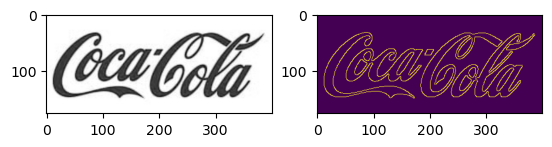

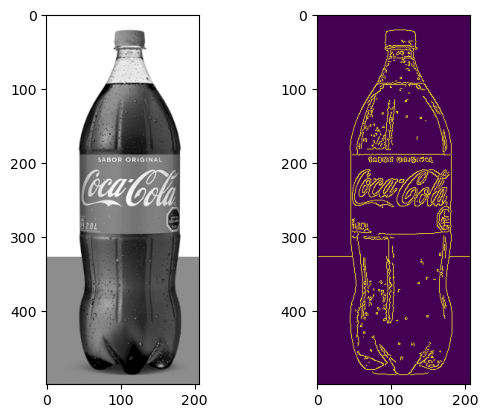

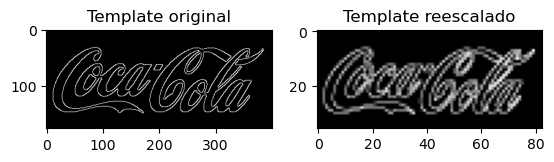

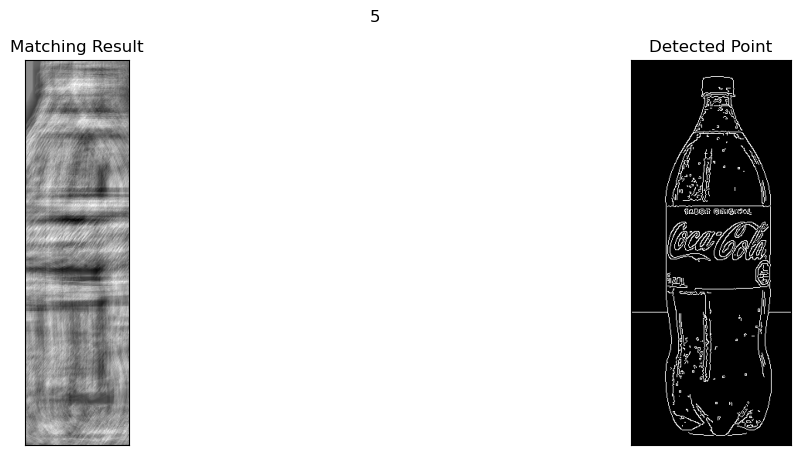

(500, 207)


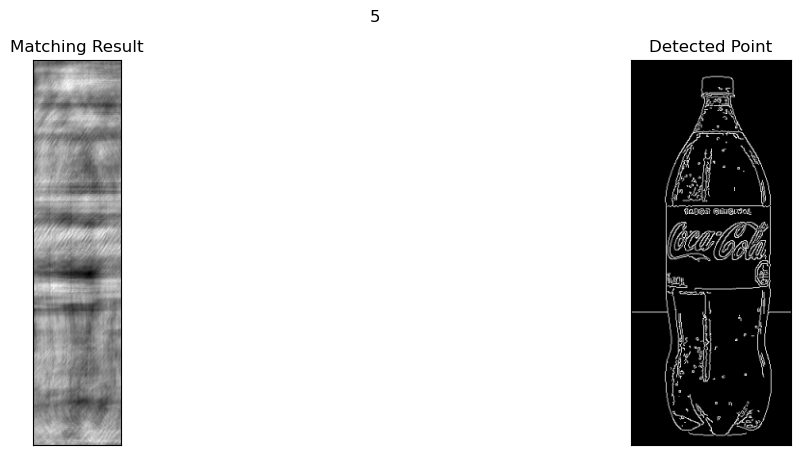

(400, 166)


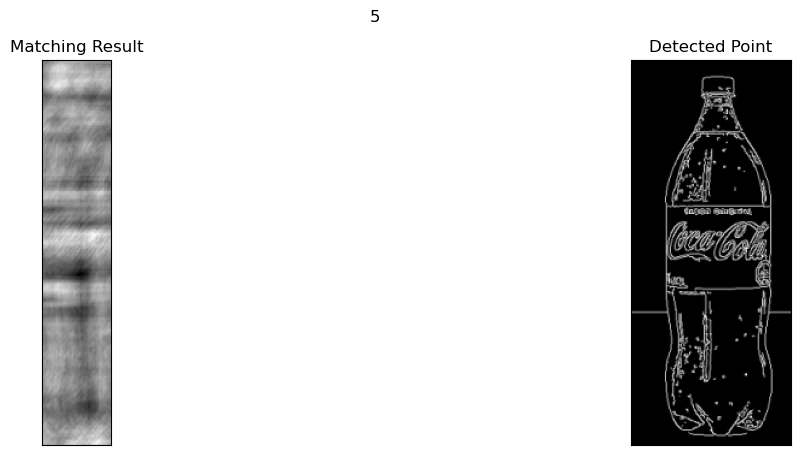

(320, 133)
Valor de confianza de deteccion: 0.5102475881576538


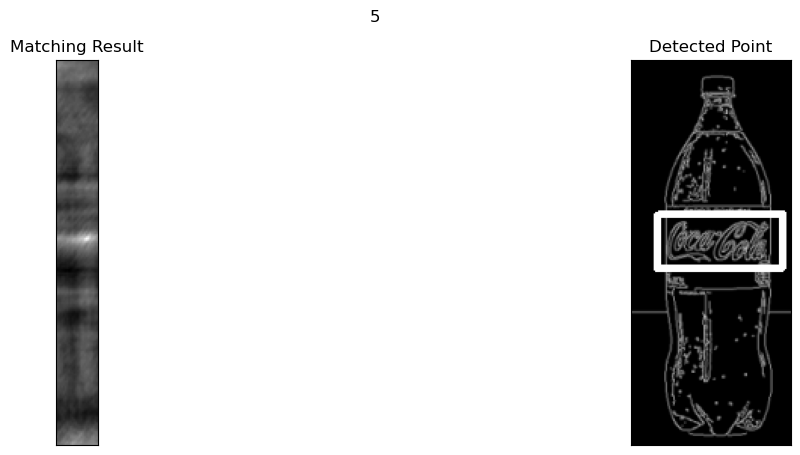

(256, 106)


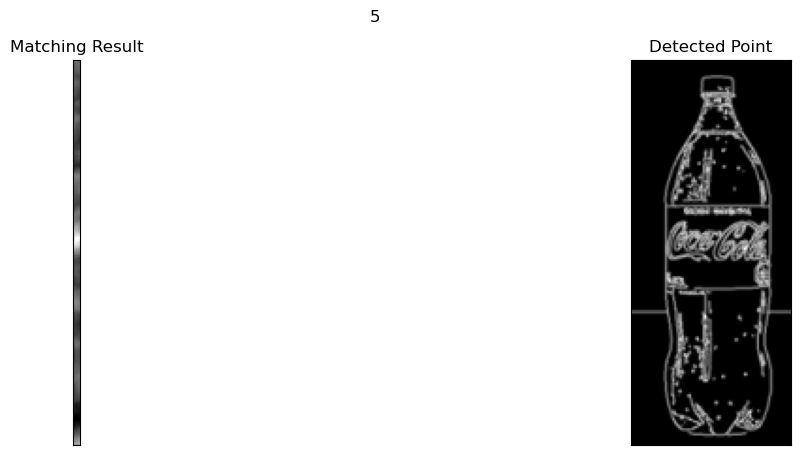

(205, 85)


In [5]:
detection_function(img_path=img_path, template_path=template_path, resize_percentaje=40, threshold=0.4)

Esto parece indicar resultados correctos, pero existe un problema. Si analizamos el valor de confianza encontramos que este es del 51%, no es muy alto. Si lo verificamos para otra imagen, tenemos:

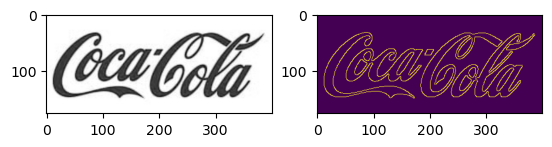

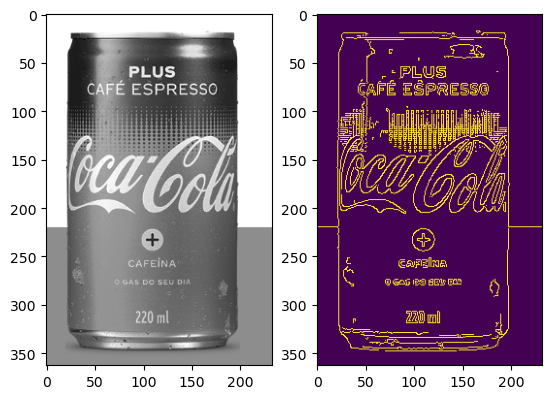

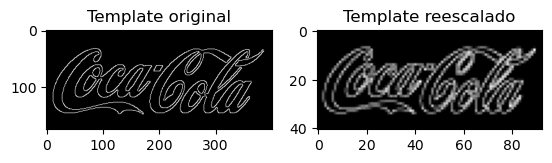

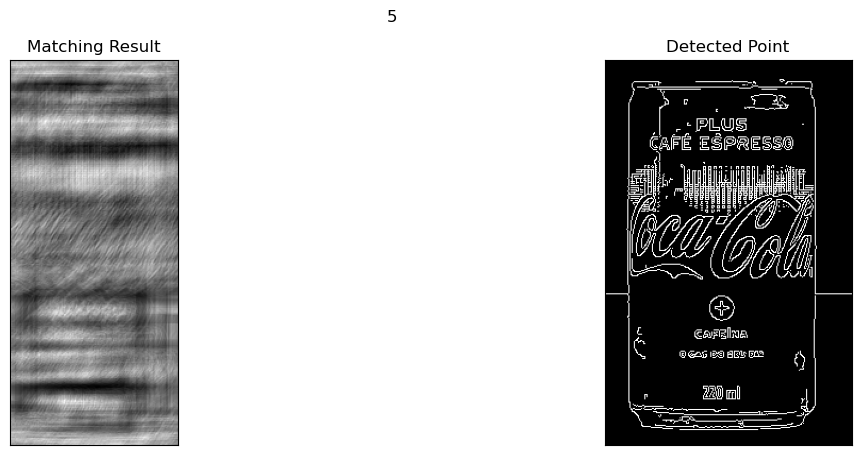

(363, 233)


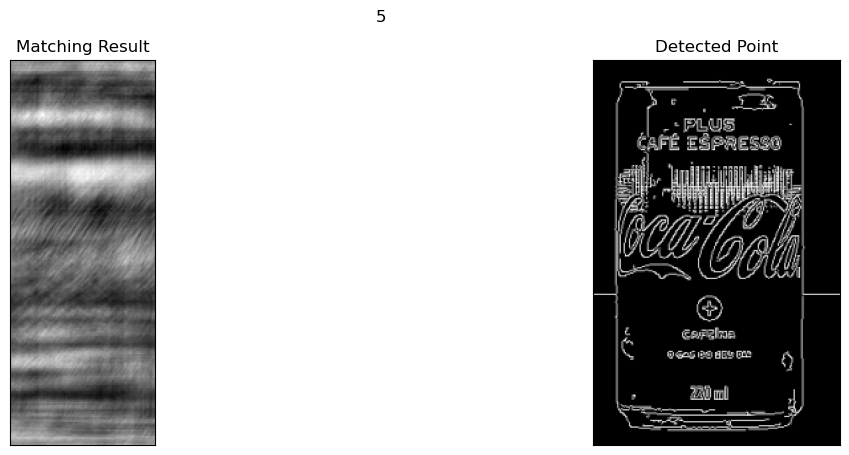

(290, 186)


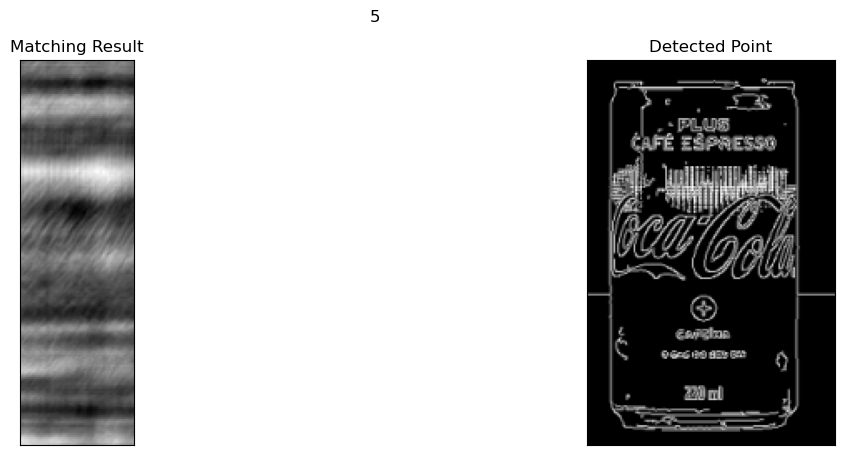

(232, 149)


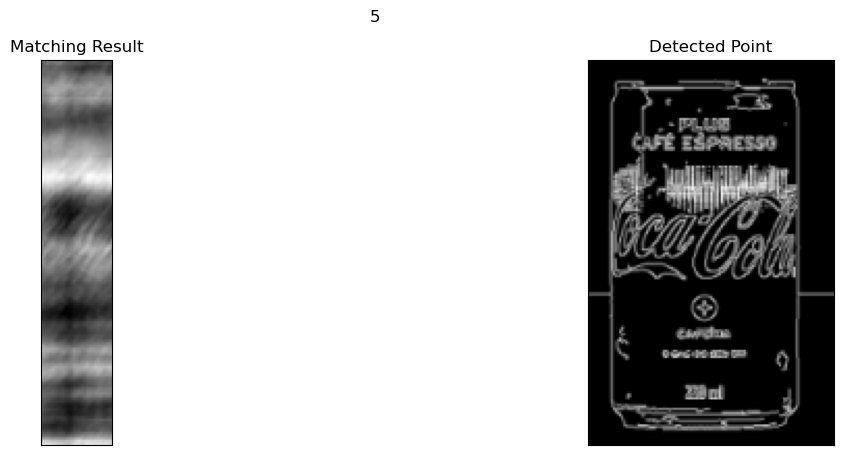

(186, 119)


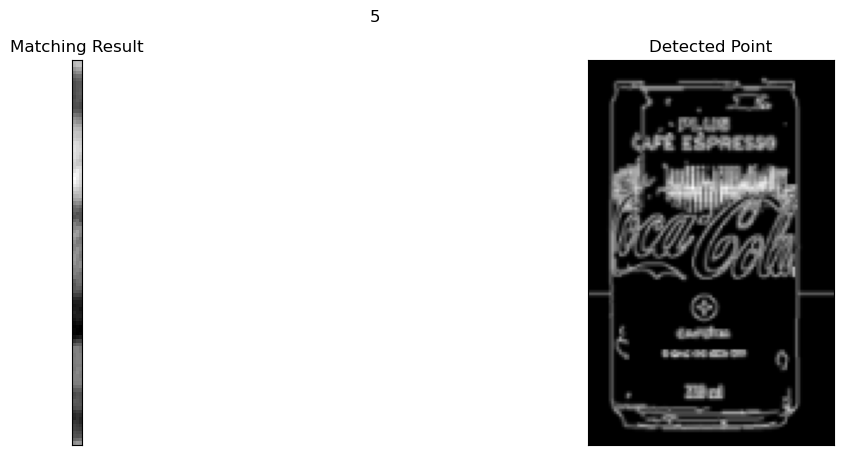

(149, 95)


In [6]:
detection_function(img_path="images/coca_logo_2.png", template_path=template_path, resize_percentaje=40, threshold=0.4)

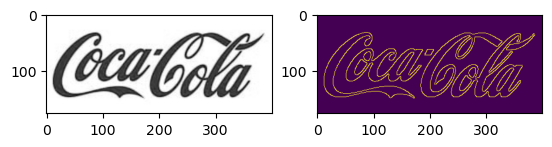

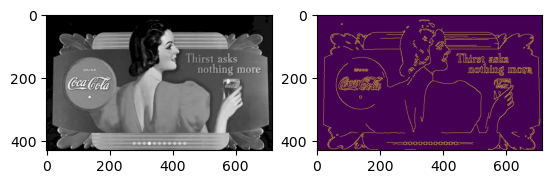

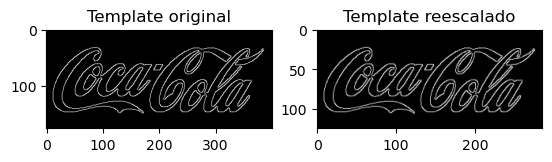

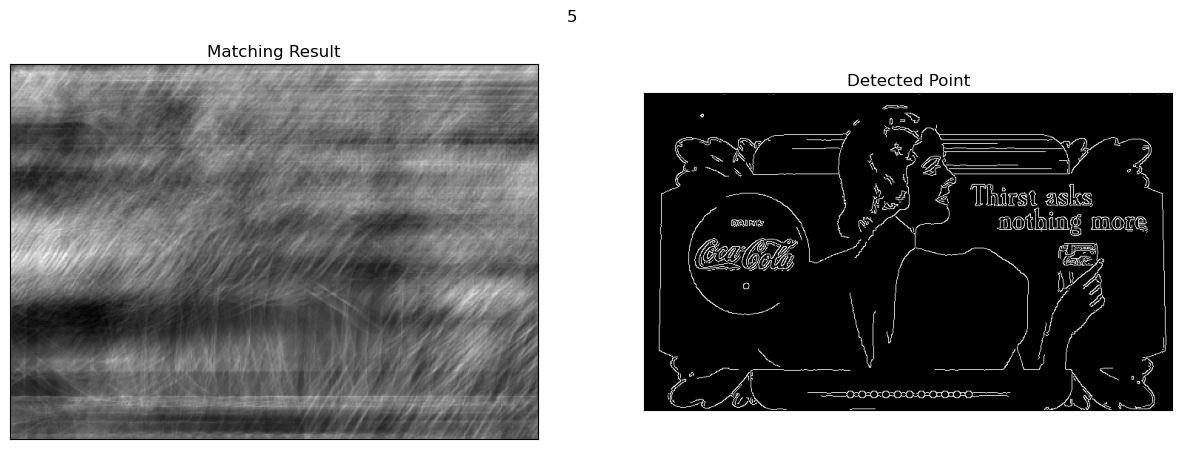

(429, 715)


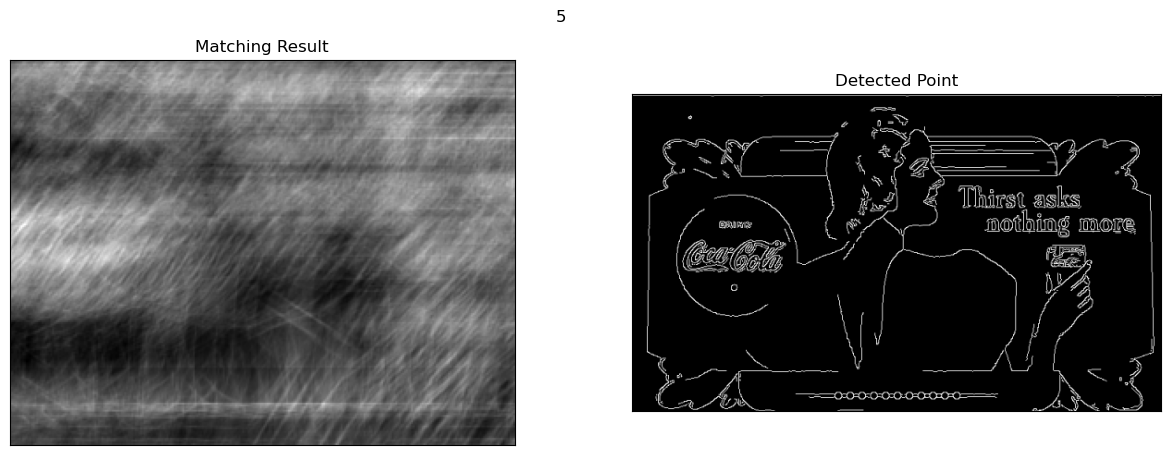

(343, 572)


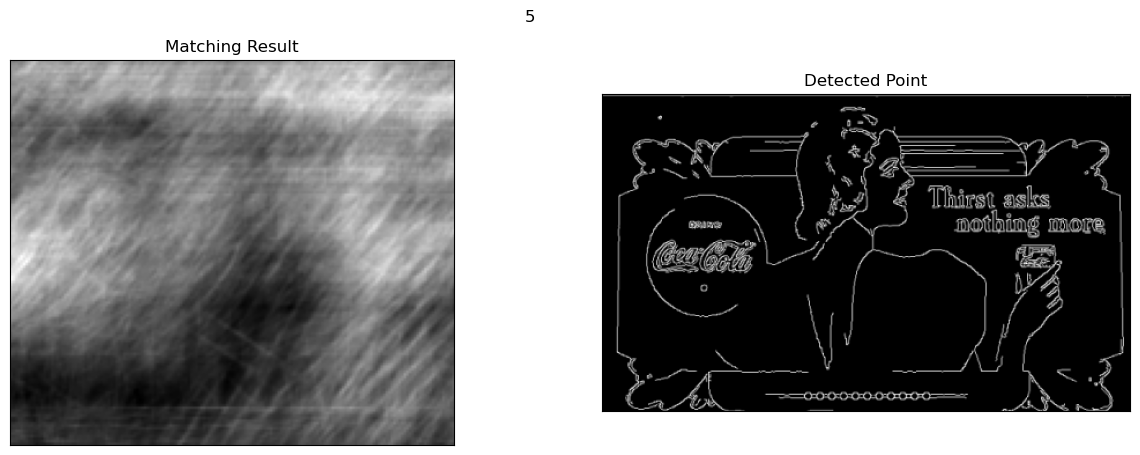

(274, 458)


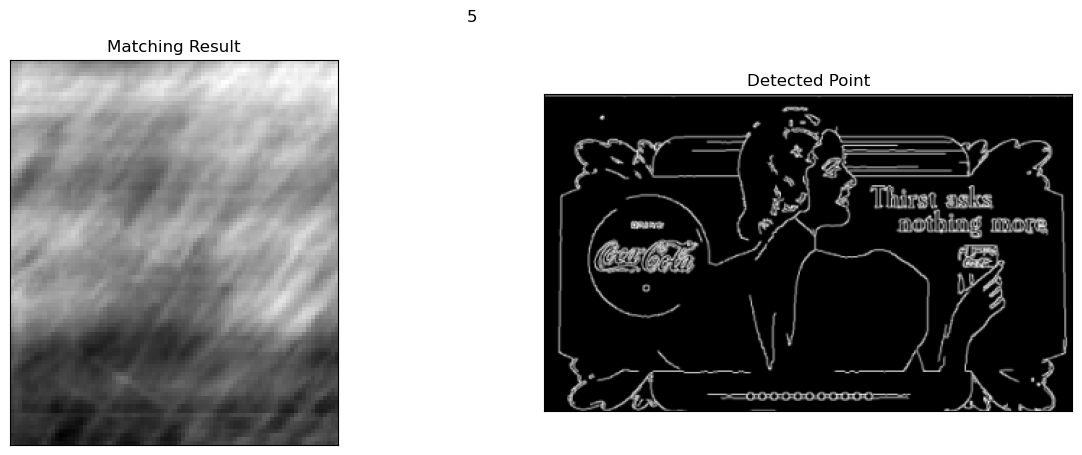

(219, 366)


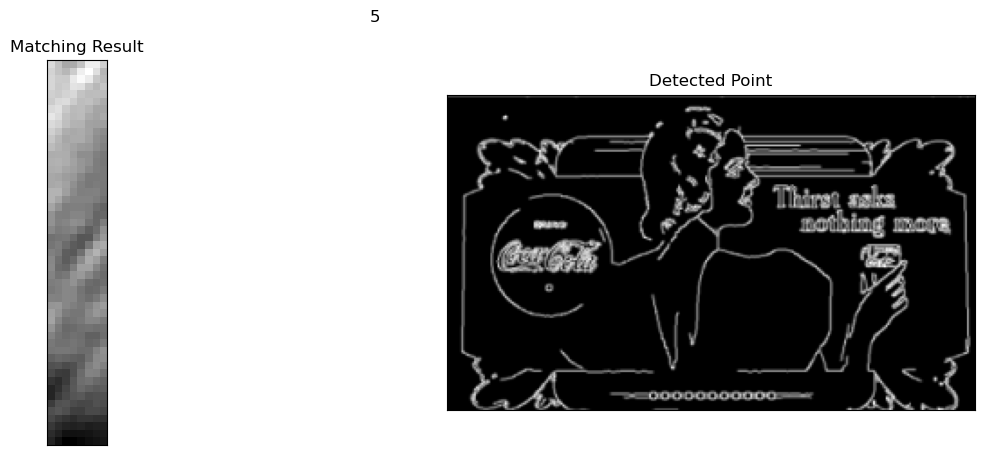

(175, 293)


In [7]:
detection_function(img_path="images/coca_retro_2.png", template_path=template_path, resize_percentaje=40, threshold=0.4)

Analizando los resultados, encontramos que si bien, la logica parecía prometedora, esta era muy poco robusta, ante cambios en la imagen, los resultados variaban de manera notable, lo que lo hacía un metodo muy poco fiable. Para diferentes imagenes, debíamos modificar los parámetros de escalado y threshhold, lo cual no era ideal para una aplicación real.

# Deteccion de features utilizando SIFT

Para probar una mejor versión de detección, se procedió utilizando el algoritmo SIFT. En principio, mejoró de forma notable la detección para algunas imagenes específicas, pero ; no corrigió completamente el problema. Se siguió utilizando la filosofía de aplicar canny para detectar bordes, asi no afectaba a la detección los tonos de grises variables del logo, o del fondo. A su vez, se decidió aplicar un filtro de sharpening (unsharp masking), con el objetivo de retirar el blur de algunas imagenes. Esto mejoró notablemente los resultados, logrando la detección de features en todas las imagenes. 

In [15]:
#Si queremos que las imágenes sean mostradas en una ventana emergente quitar el inline
%matplotlib inline
#%matplotlib qt

import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import os

Definimos funcion para realizar sharpening

In [16]:
def unsharp_mask(image, kernel_size=(5, 5), sigma=1.0, amount=1.5, threshold=0):
    """
    Apply unsharp masking to sharpen an image.

    Parameters:
        image (numpy.ndarray): Input image to be sharpened.
        kernel_size (tuple): Size of the Gaussian kernel.
        sigma (float): Standard deviation for Gaussian kernel.
        amount (float): Strength of the sharpening effect.
        threshold (int): Minimum difference to apply sharpening.

    Returns:
        numpy.ndarray: Sharpened image.
    """
    # Apply Gaussian blur to the image
    blurred = cv.GaussianBlur(image, kernel_size, sigma)

    # Calculate the difference between the original and blurred image
    sharpened = float(amount) * (image - blurred) + image

    # Apply threshold to limit sharpening to significant differences
    if threshold > 0:
        low_contrast_mask = np.abs(image - blurred) < threshold
        np.copyto(sharpened, image, where=low_contrast_mask)

    # Clip the values to be in the valid range [0, 255] for uint8 images
    sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)

    return sharpened

Para agilizar el proceso, se desarrolló esta función, que permite iterar rapidamente los principales parámetros a validar

In [17]:
def ejecucion_general(img_name):

    kernel_size=(3, 3)
    sigma=0.5
    amount=0.13
    threshold=0
    cannny_1 = 150
    canny_2= 350
    lowes_ratio = 0.80

    template = cv.imread('template/pattern.png')
    template = cv.cvtColor(template, cv.COLOR_BGR2GRAY)
    img_object = cv.Canny(template, threshold1=5, threshold2=200)



    img = cv.imread(os.path.join('images', img_name), cv.IMREAD_GRAYSCALE)
    img_scene = img.copy()
    img_scene = unsharp_mask(img_scene, kernel_size=kernel_size, sigma=sigma, amount=amount, threshold=threshold)
    
    img_scene = cv.Canny(img_scene, threshold1=cannny_1, threshold2=canny_2)

    
    if img_object is None or img_scene is None:
        print('Could not open or find the images!')
        exit(0)
    
    #-- Step 1: Detect the keypoints using SURF Detector, compute the descriptors

    # Creamos el vector de características SIFT
    sift = cv.SIFT_create()

    # Y buscamos según el algoritmo...
    keypoints_obj, descriptors_obj = sift.detectAndCompute(img_object, None)

    keypoints_scene, descriptors_scene = sift.detectAndCompute(img_scene, None)

    
    #-- Step 2: Matching descriptor vectors with a FLANN based matcher
    matcher = cv.DescriptorMatcher_create(cv.DescriptorMatcher_FLANNBASED)
    knn_matches = matcher.knnMatch(descriptors_obj, descriptors_scene, 2)
    
    #-- Filter matches using the Lowe's ratio test
    ratio_thresh = lowes_ratio
    good_matches = []
    for m,n in knn_matches:
        if m.distance < ratio_thresh * n.distance:
            good_matches.append(m)
    
    #-- Draw matches
    img_matches = np.empty((max(img_object.shape[0], img_scene.shape[0]), img_object.shape[1]+img_scene.shape[1], 3), dtype=np.uint8)
    cv.drawMatches(img_object, keypoints_obj, img_scene, keypoints_scene, good_matches, img_matches, flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    
    #-- Localize the object
    obj = np.empty((len(good_matches),2), dtype=np.float32)
    scene = np.empty((len(good_matches),2), dtype=np.float32)
    for i in range(len(good_matches)):
        #-- Get the keypoints from the good matches
        obj[i,0] = keypoints_obj[good_matches[i].queryIdx].pt[0]
        obj[i,1] = keypoints_obj[good_matches[i].queryIdx].pt[1]
        scene[i,0] = keypoints_scene[good_matches[i].trainIdx].pt[0]
        scene[i,1] = keypoints_scene[good_matches[i].trainIdx].pt[1]
    
    H, _ =  cv.findHomography(obj, scene, cv.RANSAC)
    
    #-- Get the corners from the image_1 ( the object to be "detected" )
    obj_corners = np.empty((4,1,2), dtype=np.float32)
    obj_corners[0,0,0] = 0
    obj_corners[0,0,1] = 0
    obj_corners[1,0,0] = img_object.shape[1]
    obj_corners[1,0,1] = 0
    obj_corners[2,0,0] = img_object.shape[1]
    obj_corners[2,0,1] = img_object.shape[0]
    obj_corners[3,0,0] = 0
    obj_corners[3,0,1] = img_object.shape[0]
    
    scene_corners = cv.perspectiveTransform(obj_corners, H)
    
    #-- Draw lines between the corners (the mapped object in the scene - image_2 )
    cv.line(img_matches, (int(scene_corners[0,0,0] + img_object.shape[1]), int(scene_corners[0,0,1])),\
        (int(scene_corners[1,0,0] + img_object.shape[1]), int(scene_corners[1,0,1])), (0,255,0), 4)
    cv.line(img_matches, (int(scene_corners[1,0,0] + img_object.shape[1]), int(scene_corners[1,0,1])),\
        (int(scene_corners[2,0,0] + img_object.shape[1]), int(scene_corners[2,0,1])), (0,255,0), 4)
    cv.line(img_matches, (int(scene_corners[2,0,0] + img_object.shape[1]), int(scene_corners[2,0,1])),\
        (int(scene_corners[3,0,0] + img_object.shape[1]), int(scene_corners[3,0,1])), (0,255,0), 4)
    cv.line(img_matches, (int(scene_corners[3,0,0] + img_object.shape[1]), int(scene_corners[3,0,1])),\
        (int(scene_corners[0,0,0] + img_object.shape[1]), int(scene_corners[0,0,1])), (0,255,0), 4)
    

    plt.figure(figsize=(15, 10))
    plt.imshow(cv.cvtColor(img_matches, cv.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

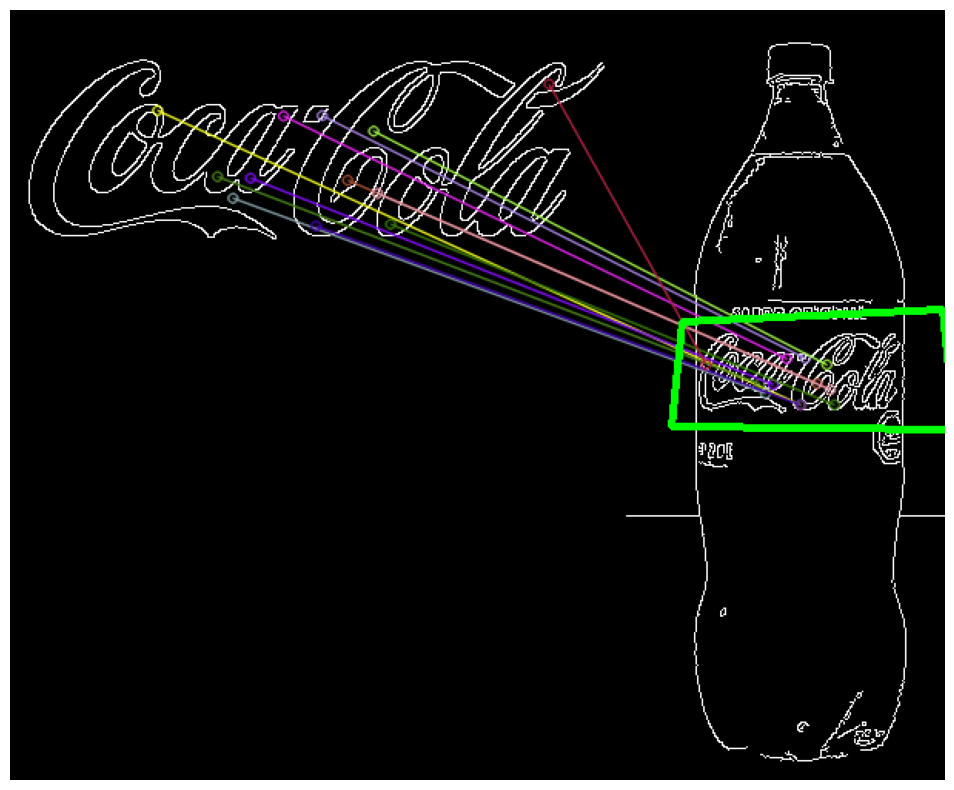

In [18]:
ejecucion_general(img_name="coca_logo_1.png")

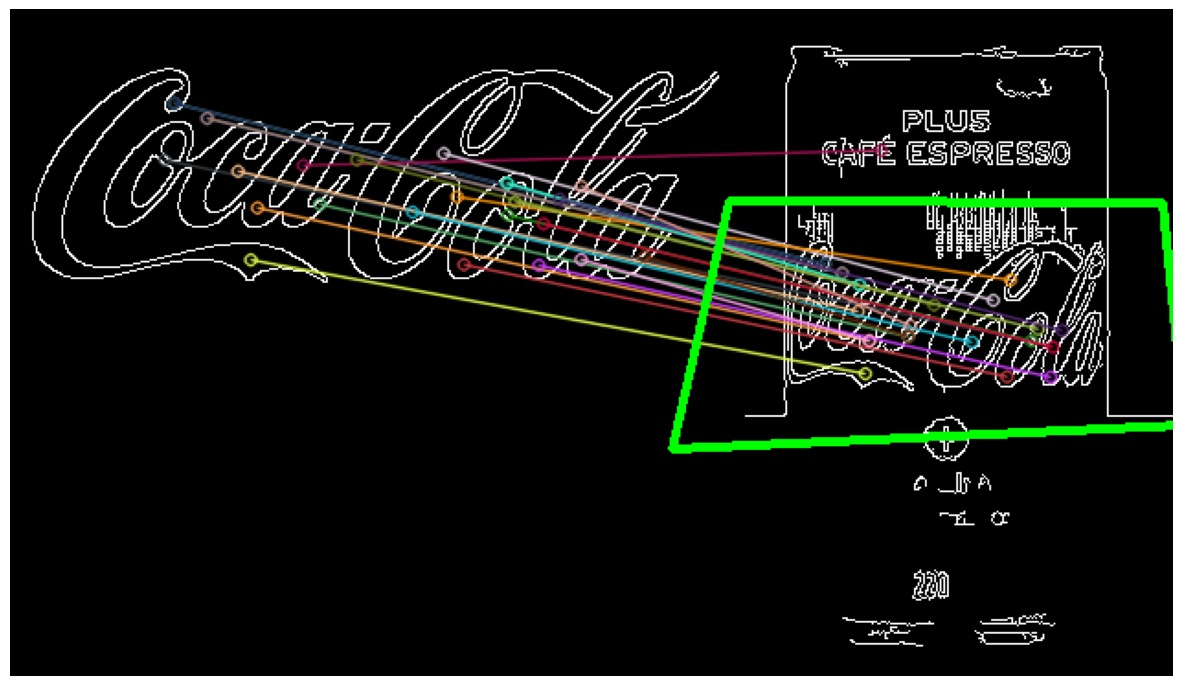

In [19]:
ejecucion_general(img_name="coca_logo_2.png")

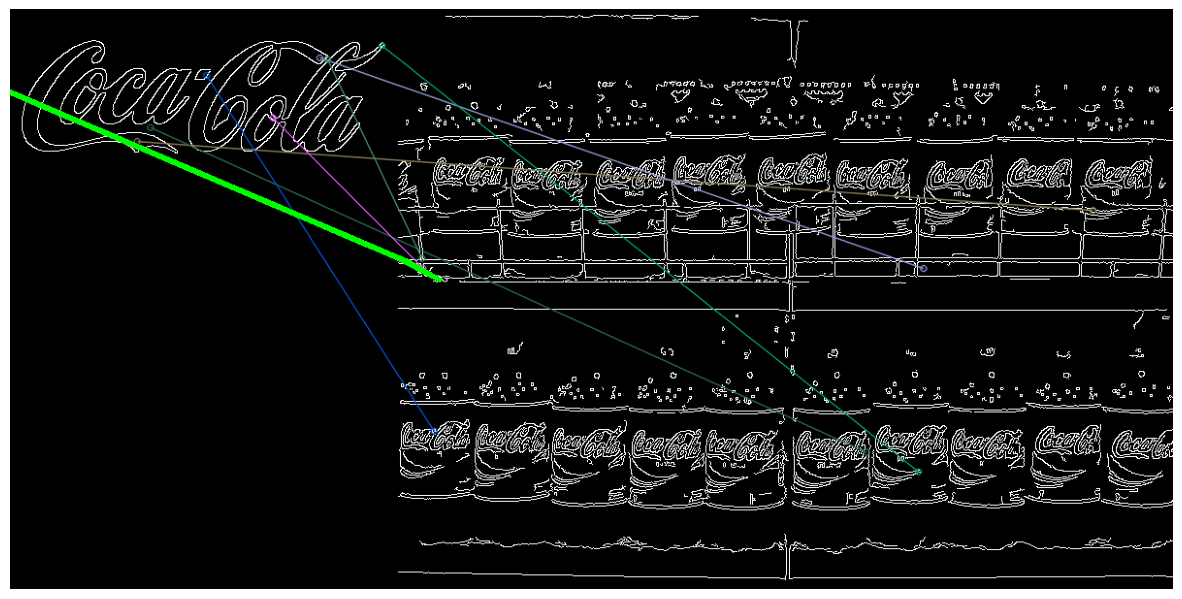

In [27]:
ejecucion_general(img_name="coca_multi.png")

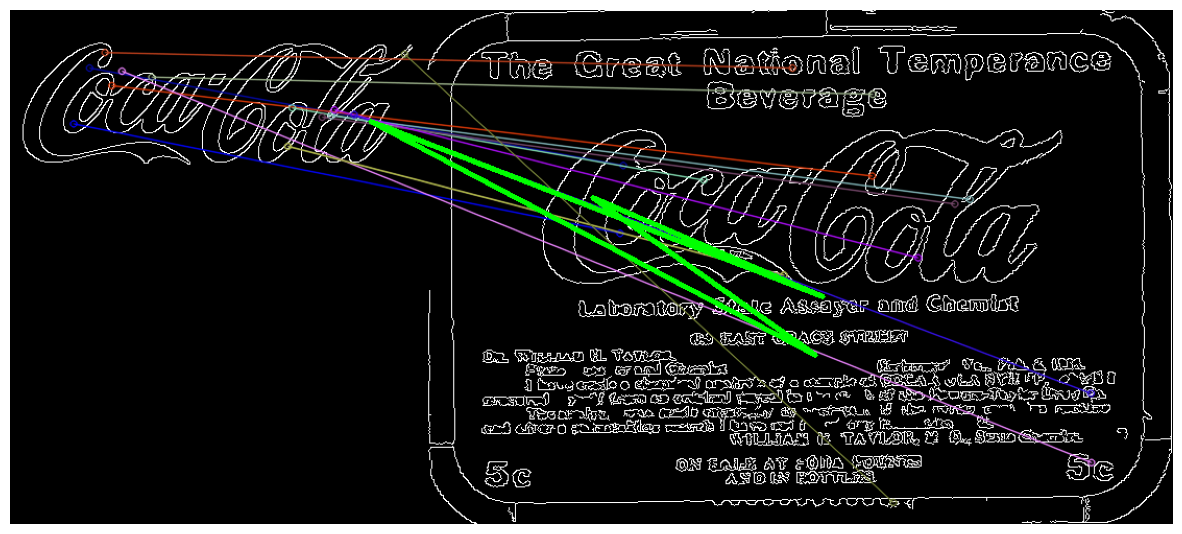

In [35]:
ejecucion_general(img_name="coca_retro_1.png")

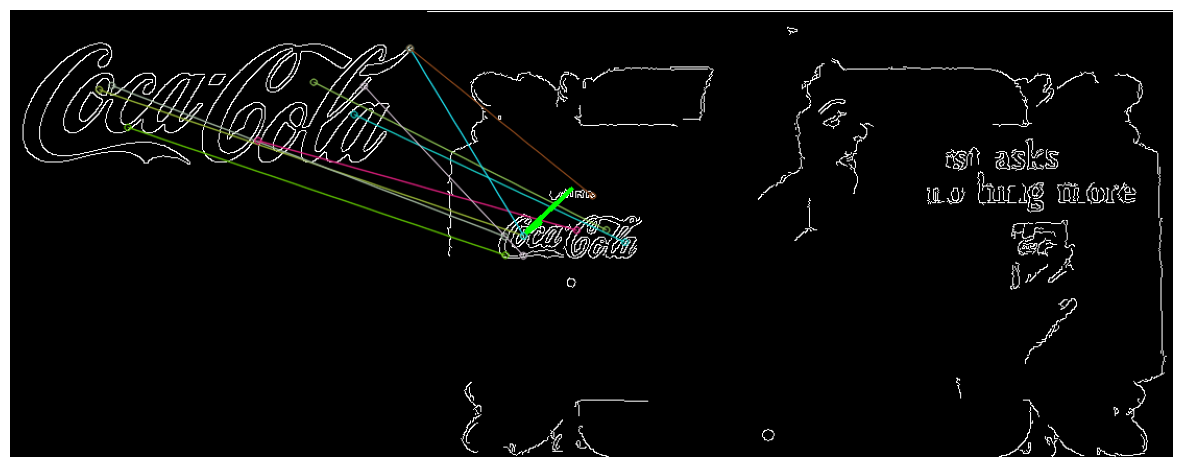

In [48]:
ejecucion_general(img_name="coca_retro_2.png")

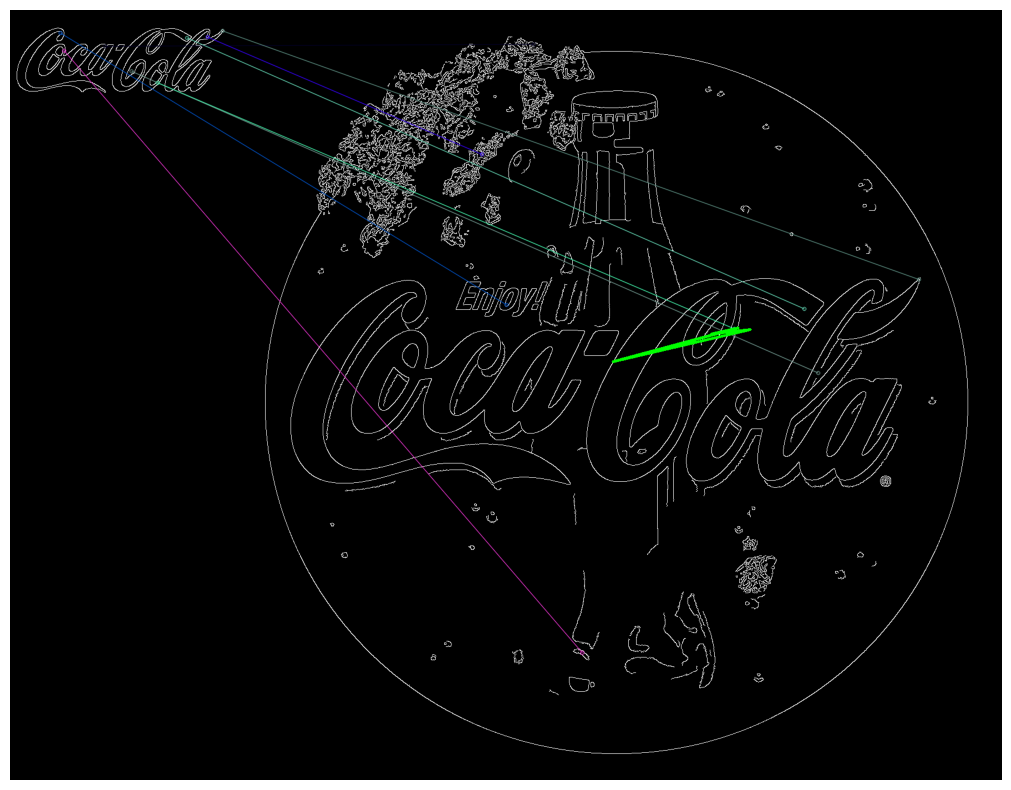

In [79]:
ejecucion_general(img_name="COCA-COLA-LOGO.jpg")

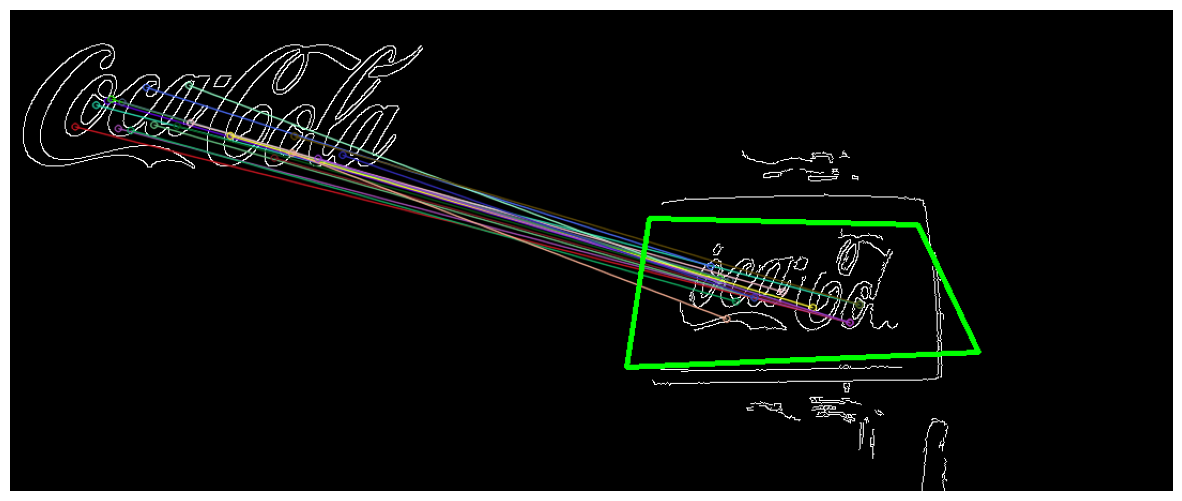

In [ ]:
ejecucion_general(img_name="logo_1.png")

Podemos ver como la utilización de SIFT mejoró notablemente las detecciones de features. A su vez encontramos que se pudo mediante la misma función(sin modificar parámetros internos de esta) lograr detecciones en casi todas las imagenes: en la de coca colas multiples uno de los features detectados es correcto, mientras que los demás no.

Con estos resultados, podrían optarse por dos caminos diferentes:
1) Aplicar parámetros distintos para cada una de las imágenes, mejorando los resultados a costa de perder capacidad de generalización
1) Incorporar nuevas metodologías de preprocesado: con las eleccion de mejores técnicas de preprocesado, puede ser posible mejorar los resultados obtenidos, sin necesidad de tener que aplicar parámetros específicos para cada imagen.

Otro aspecto que podría evaluarse para las imagenes que presentan múltiples detecciones sería utilizar una metodología híbrida: 
1) Utilizar un sift muy robusto al principio para detectar features en uno de los logos de la imagen
1) Aplicar un filtro de cercanía para asegurarnos de quedarnos con las detecciones que corresponden todas al mismo logo
1) Identificar el tamaño al cual debería ser reescalado el template en base a los features detectados
1) Aplicar template matching para intentar detectar nuevos logos.

## Ejercicio 2 (template matching)

Para poder resolver específicamente este ejercicio, se optó por el siguiente camino:

1) Identificar la relación de tamaños entre el template y los logos de coca cola en la imagen a detectar
1) Escalar el logo de template para que sea lo mas similar posible a los logos a detectar
1) Binzarizar la imagen y el template para retirar la influencia de diferentes colores y fondos
1) Aplicar template matching
1) Dibujar bounding boxes

Los resultados de esto se muestran a continuacion

In [5]:
def draw_bounding_box(image_path):
    """
    Allows the user to manually draw a bounding box on an image and returns the bounding box size.

    Parameters:
        image_path (str): Path to the image file.

    Returns:
        tuple: Bounding box size (width, height).
    """
    # Load the image
    image = cv.imread(image_path)
    if image is None:
        print("Could not open or find the image!")
        return None

    # Display the image and let the user draw a bounding box
    bbox = cv.selectROI("Select ROI", image, fromCenter=False, showCrosshair=True)

    # Close the ROI selection window
    cv.destroyAllWindows()

    # Extract bounding box size
    x, y, w, h = bbox
    print(f"Bounding box size: Width={w}, Height={h}")
    return w, h

# Example usage
image_path = "images/coca_multi.png"
# bounding_box_size = draw_bounding_box(image_path)

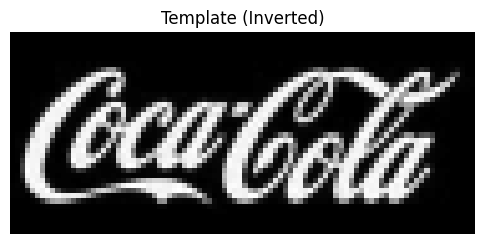

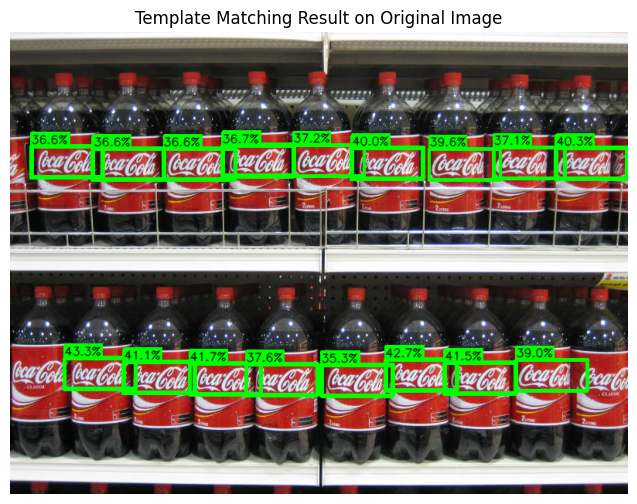

Detected bounding boxes: [(np.int64(275), np.int64(144), 92, 40, 0.35438427329063416), (np.int64(276), np.int64(144), 92, 40, 0.3692273795604706), (np.int64(274), np.int64(145), 92, 40, 0.37592124938964844), (np.int64(275), np.int64(145), 92, 40, 0.45921266078948975), (np.int64(276), np.int64(145), 92, 40, 0.40681973099708557), (np.int64(366), np.int64(145), 92, 40, 0.36703693866729736), (np.int64(27), np.int64(146), 92, 40, 0.39692211151123047), (np.int64(28), np.int64(146), 92, 40, 0.44920262694358826), (np.int64(29), np.int64(146), 92, 40, 0.38508448004722595), (np.int64(273), np.int64(146), 92, 40, 0.3597153425216675), (np.int64(274), np.int64(146), 92, 40, 0.47002848982810974), (np.int64(275), np.int64(146), 92, 40, 0.5092278122901917), (np.int64(276), np.int64(146), 92, 40, 0.410326212644577), (np.int64(365), np.int64(146), 92, 40, 0.35910487174987793), (np.int64(366), np.int64(146), 92, 40, 0.3976949155330658), (np.int64(26), np.int64(147), 92, 40, 0.3877171576023102), (np.int64

In [14]:
def template_matching_with_binarization(image_path, template_path, method=cv.TM_CCOEFF_NORMED, threshold=0.8, template_new_width=70):
    """
    Perform template matching with binarization to find the template in the given image.

    Parameters:
        image_path (str): Path to the image file.
        template_path (str): Path to the template file.
        method (int): Template matching method (default: cv.TM_CCOEFF_NORMED).
        threshold (float): Threshold for detection (default: 0.8).

    Returns:
        list: List of bounding boxes where the template is detected.
    """
    # Load the image and template
    image = cv.imread(image_path, cv.IMREAD_GRAYSCALE)
    original_image = cv.imread(image_path)  # Load the original image in color
    template = cv.imread(template_path, cv.IMREAD_GRAYSCALE)

    if image is None or template is None:
        print("Could not open or find the image or template!")
        return []

    # Resize the template to the specified width while maintaining aspect ratio
    template_height, template_width = template.shape
    aspect_ratio = template_height / template_width
    new_height = int(template_new_width * aspect_ratio)
    template = cv.resize(template, (template_new_width, new_height), interpolation=cv.INTER_AREA)

    # Invert the template colors (exchange black and white values)
    template = cv.bitwise_not(template)

    # Display the template
    plt.figure(figsize=(6, 4))
    plt.imshow(template, cmap='gray')
    plt.title('Template (Inverted)')
    plt.axis('off')
    plt.show()

    # Binarize the image and template
    _, image_bin = cv.threshold(image, 128, 255, cv.THRESH_BINARY | cv.THRESH_OTSU)
    _, template_bin = cv.threshold(template, 128, 255, cv.THRESH_BINARY | cv.THRESH_OTSU)

    # Perform template matching
    result = cv.matchTemplate(image_bin, template_bin, method)
    locations = np.where(result >= threshold)

    # Dibujar bounding boxes y mostrar confianza
    bounding_boxes = []
    for pt in zip(*locations[::-1]):
        x, y = pt
        w, h = template_new_width, new_height

        # Confianza directamente del resultado normalizado
        conf = float(result[y, x])

        bounding_boxes.append((x, y, w, h, conf))

        cv.rectangle(original_image, (x, y), (x + w, y + h), (0, 255, 0), 2)

        # Etiqueta con la confianza
        label = f"{conf*100:.1f}%"
        (tw, th), baseline = cv.getTextSize(label, cv.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv.rectangle(original_image, (x, y - th - baseline), (x + tw, y), (0, 255, 0), -1)
        cv.putText(original_image, label, (x, y - baseline),
                cv.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1, cv.LINE_AA)

    # Mostrar resultado
    plt.figure(figsize=(10, 6))
    plt.imshow(cv.cvtColor(original_image, cv.COLOR_BGR2RGB))
    plt.title('Template Matching Result on Original Image')
    plt.axis('off')
    plt.show()

    return bounding_boxes

# Example usage
bounding_boxes = template_matching_with_binarization(image_path, template_path, threshold=0.35, template_new_width=92)
print("Detected bounding boxes:", bounding_boxes)

Con ello podemos ver que tenemos una tecnica para poder detectar correctamente multiples logos de coca cola en una imagen. Con esta solución específica, se requeriría de un entorno muy controlado, ya que fue necesario ajustar hasta el punto optimo los tamaños del template para lograr que esto funcione correctamente. Los resultados del template matching se vieron mejorados significativamente cuando aplicamos procesamientos previos a la detección, los cuales nos permitieron diferenciar mas el logo de las botellas del fondo. 